In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import subprocess, sys
def pip(args):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + args, check=True)
pip(['numpy>=2.0', '--force-reinstall'])
pip(['scipy>=1.13', '--force-reinstall'])
pip(['datasets', 'sacrebleu', 'sacremoses',
     'nltk', 'tokenizers', 'sentencepiece'])
pip(['bert-score'])
pip(['unbabel-comet'])
print('✅ Cài xong toàn bộ — đang restart kernel...')
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 81.2 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
unbabel-comet 2.2.7 requires numpy<2.0.0,>=1.20.0, but you have numpy 2.4.4 which is incompatible.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but y

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 55.6 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
unbabel-comet 2.2.7 requires numpy<2.0.0,>=1.20.0, but you have numpy 2.4.4 which is incompatible.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
ydata-profiling 4.18.1 requires scipy<1.17,>=1.8, but you have scipy 1.17.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you

✅ Cài xong toàn bộ — đang restart kernel...


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
ydata-profiling 4.18.1 requires scipy<1.17,>=1.8, but you have scipy 1.17.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 whi

{'status': 'ok', 'restart': True}

In [1]:
import os, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display, clear_output, HTML
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast  # mixed precision cho T4

from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

import sacrebleu
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import word_tokenize
from bert_score import score as bert_score_fn
from comet import download_model, load_from_checkpoint

class Config:
    # Dữ liệu
    MAX_LEN         = 100      # giới hạn độ dài câu
    VOCAB_SIZE      = 16000   # kích thước từ điển BPE
    TRAIN_LIMIT     = 80000   # số câu train (None = dùng hết)
    # Kiến trúc Transformer
    D_MODEL         = 256
    N_HEADS         = 8
    N_ENC_LAYERS    = 3
    N_DEC_LAYERS    = 3
    D_FF            = 512
    DROPOUT         = 0.1
    # Huấn luyện
    BATCH_SIZE      = 128     # T4 16GB chịu được batch 128
    N_EPOCHS        = 20
    CLIP            = 1.0
    WARMUP_STEPS    = 4000
    LABEL_SMOOTHING = 0.1
    # Metrics (tính mỗi N epoch — COMET & BERTScore chậm)
    METRIC_EVERY    = 2       # tính đầy đủ 5 chỉ số mỗi 2 epoch
    N_EVAL_SAMPLES  = 300    # số câu dùng để tính metrics nhanh
    # Token đặc biệt
    PAD_IDX = 0; UNK_IDX = 1; BOS_IDX = 2; EOS_IDX = 3
    DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
    SEED    = 42

cfg = Config()
torch.manual_seed(cfg.SEED)
np.random.seed(cfg.SEED)

if cfg.DEVICE == 'cuda':
    print(f'✅ GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('⚠️  Không có GPU — hãy bật GPU T4 trong Settings')

2026-05-14 12:38:50.712436: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778762330.920060     174 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778762330.973791     174 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778762331.472806     174 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778762331.472855     174 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778762331.472859     174 computation_placer.cc:177] computation placer alr

✅ GPU: Tesla T4
   VRAM: 15.6 GB


In [2]:
print('⏳ Đang tải dataset...')
raw_ds     = load_dataset('thainq107/iwslt2015-en-vi')
train_data = raw_ds['train']
val_data   = raw_ds['validation']
test_data  = raw_ds['test']

print(f'✅ Train: {len(train_data):,} | Val: {len(val_data):,} | Test: {len(test_data):,}')
print('\n3 câu mẫu:')
for i in range(3):
    ex = train_data[i]
    print(f'  EN: {ex["en"][:70]}')
    print(f'  VI: {ex["vi"][:70]}\n')

⏳ Đang tải dataset...


README.md:   0%|          | 0.00/522 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/181k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/133317 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1268 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1268 [00:00<?, ? examples/s]

✅ Train: 133,317 | Val: 1,268 | Test: 1,268

3 câu mẫu:
  EN: Rachel Pike : The science behind a climate headline
  VI: Khoa học đằng sau một tiêu đề về khí hậu

  EN: In 4 minutes , atmospheric chemist Rachel Pike provides a glimpse of t
  VI: Trong 4 phút , chuyên gia hoá học khí quyển Rachel Pike giới thiệu sơ 

  EN: I &apos;d like to talk to you today about the scale of the scientific 
  VI: Tôi muốn cho các bạn biết về sự to lớn của những nỗ lực khoa học đã gó



In [3]:
TOKENIZER_PATH = '/kaggle/working/bpe_tokenizer.json'

if not os.path.exists(TOKENIZER_PATH):
    print('🔧 Đang huấn luyện BPE tokenizer...')
    tokenizer = Tokenizer(BPE(unk_token='[UNK]'))
    tokenizer.pre_tokenizer = Whitespace()
    trainer = BpeTrainer(
        vocab_size=cfg.VOCAB_SIZE,
        special_tokens=['[PAD]', '[UNK]', '[BOS]', '[EOS]'],
        min_frequency=2
    )
    corpus = [s for ex in train_data for s in (ex['en'], ex['vi'])]
    tokenizer.train_from_iterator(corpus, trainer)
    tokenizer.save(TOKENIZER_PATH)
    print('✅ Tokenizer đã lưu.')
else:
    tokenizer = Tokenizer.from_file(TOKENIZER_PATH)
    print('✅ Tokenizer đã tải từ file.')

VOCAB_SIZE_REAL = tokenizer.get_vocab_size()
print(f'   Vocab size thực: {VOCAB_SIZE_REAL}')

def encode(text, max_len=cfg.MAX_LEN):
    ids = tokenizer.encode(text).ids
    return [cfg.BOS_IDX] + ids[:max_len - 2] + [cfg.EOS_IDX]

def decode_ids(ids):
    ids = [i for i in ids if i not in (cfg.BOS_IDX, cfg.EOS_IDX, cfg.PAD_IDX)]
    return tokenizer.decode(ids)

🔧 Đang huấn luyện BPE tokenizer...



✅ Tokenizer đã lưu.
   Vocab size thực: 16000


In [4]:
class TranslationDataset(Dataset):
    def __init__(self, data, limit=None):
        items = data if limit is None else data.select(range(min(limit, len(data))))
        print(f'  Đang mã hoá {len(items):,} câu...', end='')
        self.pairs = [(encode(ex['en']), encode(ex['vi'])) for ex in items]
        print(' xong!')

    def __len__(self): return len(self.pairs)
    def __getitem__(self, i): return self.pairs[i]

def collate_fn(batch):
    src_b, tgt_b = zip(*batch)
    ms = max(len(s) for s in src_b)
    mt = max(len(t) for t in tgt_b)
    sp = torch.tensor([s + [cfg.PAD_IDX]*(ms-len(s)) for s in src_b], dtype=torch.long)
    tp = torch.tensor([t + [cfg.PAD_IDX]*(mt-len(t)) for t in tgt_b], dtype=torch.long)
    return sp, tp

print('Đang tạo dataset...')
train_ds = TranslationDataset(train_data, limit=cfg.TRAIN_LIMIT)
val_ds   = TranslationDataset(val_data)
test_ds  = TranslationDataset(test_data)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                           collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False,
                           collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE, shuffle=False,
                           collate_fn=collate_fn, num_workers=2, pin_memory=True)
print(f'✅ Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Đang tạo dataset...
  Đang mã hoá 80,000 câu... xong!
  Đang mã hoá 1,268 câu... xong!
  Đang mã hoá 1,268 câu... xong!
✅ Train batches: 625 | Val: 10 | Test: 10


In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class TransformerNMT(nn.Module):
    def __init__(self):
        super().__init__()
        self.d = cfg.D_MODEL
        self.src_emb = nn.Embedding(VOCAB_SIZE_REAL, cfg.D_MODEL, padding_idx=cfg.PAD_IDX)
        self.tgt_emb = nn.Embedding(VOCAB_SIZE_REAL, cfg.D_MODEL, padding_idx=cfg.PAD_IDX)
        self.pe      = PositionalEncoding(cfg.D_MODEL, cfg.DROPOUT)
        self.tf      = nn.Transformer(
            d_model=cfg.D_MODEL, nhead=cfg.N_HEADS,
            num_encoder_layers=cfg.N_ENC_LAYERS,
            num_decoder_layers=cfg.N_DEC_LAYERS,
            dim_feedforward=cfg.D_FF,
            dropout=cfg.DROPOUT, batch_first=True)
        self.proj = nn.Linear(cfg.D_MODEL, VOCAB_SIZE_REAL)
        self._init()

    def _init(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src, tgt):
        sm = (src == cfg.PAD_IDX)
        tm = (tgt == cfg.PAD_IDX)
        cm = nn.Transformer.generate_square_subsequent_mask(
            tgt.size(1), device=tgt.device)
        se = self.pe(self.src_emb(src) * math.sqrt(self.d))
        te = self.pe(self.tgt_emb(tgt) * math.sqrt(self.d))
        o  = self.tf(se, te, tgt_mask=cm,
                    src_key_padding_mask=sm,
                    tgt_key_padding_mask=tm,
                    memory_key_padding_mask=sm)
        return self.proj(o)

    @torch.no_grad()
    def translate(self, src_t, max_len=cfg.MAX_LEN):
        self.eval()
        sm  = (src_t == cfg.PAD_IDX)
        se  = self.pe(self.src_emb(src_t) * math.sqrt(self.d))
        mem = self.tf.encoder(se, src_key_padding_mask=sm)
        ys  = torch.tensor([[cfg.BOS_IDX]], device=src_t.device)
        for _ in range(max_len):
            te  = self.pe(self.tgt_emb(ys) * math.sqrt(self.d))
            cm  = nn.Transformer.generate_square_subsequent_mask(
                ys.size(1), device=ys.device)
            out = self.tf.decoder(te, mem, tgt_mask=cm)
            nxt = self.proj(out[:, -1:]).argmax(-1)
            ys  = torch.cat([ys, nxt], dim=1)
            if nxt.item() == cfg.EOS_IDX:
                break
        return ys[0].tolist()

model = TransformerNMT().to(cfg.DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model: {n_params/1e6:.2f}M params trên {cfg.DEVICE.upper()}')

✅ Model: 16.26M params trên CUDA


In [6]:
class LabelSmoothLoss(nn.Module):
    def __init__(self, vocab, pad, smooth=0.1):
        super().__init__()
        self.pad=pad; self.smooth=smooth; self.V=vocab

    def forward(self, pred, tgt):
        sv = self.smooth / (self.V - 2)
        with torch.no_grad():
            sd = torch.full_like(pred, sv)
            sd.scatter_(1, tgt.unsqueeze(1), 1.0 - self.smooth)
            sd[:, self.pad] = 0
            mask = (tgt == self.pad); sd[mask] = 0
        lp = torch.log_softmax(pred, -1)
        return -(sd * lp).sum() / (~mask).sum()

class WarmupScheduler:
    def __init__(self, opt, d, ws):
        self.opt=opt; self.d=d; self.ws=ws; self._step=0; self._rate=0
    def step(self):
        self._step += 1
        r = self.d**(-0.5) * min(self._step**(-0.5), self._step * self.ws**(-1.5))
        for p in self.opt.param_groups: p['lr'] = r
        self._rate = r

criterion = LabelSmoothLoss(VOCAB_SIZE_REAL, cfg.PAD_IDX, cfg.LABEL_SMOOTHING)
optimizer  = optim.Adam(model.parameters(), lr=0, betas=(0.9,0.98), eps=1e-9)
scheduler  = WarmupScheduler(optimizer, cfg.D_MODEL, cfg.WARMUP_STEPS)
scaler     = GradScaler()   # AMP scaler cho T4
print('✅ Loss / Optimizer / Scheduler / AMP Scaler sẵn sàng')

✅ Loss / Optimizer / Scheduler / AMP Scaler sẵn sàng


In [9]:
print('⏳ Đang tải COMET (lần đầu ~2GB, sẽ cache lại)...')
comet_path  = download_model('Unbabel/wmt22-comet-da')
comet_model = load_from_checkpoint(comet_path)
comet_model = comet_model.to(cfg.DEVICE)
print('✅ COMET model sẵn sàng!')

⏳ Đang tải COMET (lần đầu ~2GB, sẽ cache lại)...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/huggingface/hub/models--Unbabel--wmt22-comet-da/snapshots/2760a223ac957f30acfb18c8aa649b01cf1d75f2/checkpoints/model.ckpt`


✅ COMET model sẵn sàng!


In [13]:
def get_translations(model, loader, srcs_raw, n=cfg.N_EVAL_SAMPLES):
    model.eval(); hyps=[]; refs=[]; src_texts=[]; cnt=0
    with torch.no_grad():
        for src_b, tgt_b in loader:
            src_b = src_b.to(cfg.DEVICE)
            for i in range(src_b.size(0)):
                hyps.append(decode_ids(model.translate(src_b[i:i+1])))
                refs.append(decode_ids(tgt_b[i].tolist()))
                src_texts.append(srcs_raw[cnt])
                cnt += 1
                if cnt >= n: break
            if cnt >= n: break
    return hyps, refs, src_texts

# Cache raw val sources
val_srcs_raw = [val_data[i]['en'] for i in range(min(cfg.N_EVAL_SAMPLES, len(val_data)))]

def calc_bleu(hyps, refs):
    return round(sacrebleu.corpus_bleu(hyps, [refs]).score, 2)

def calc_meteor(hyps, refs):
    scores = []
    for h, r in zip(hyps, refs):
        ht = word_tokenize(h.lower())
        rt = word_tokenize(r.lower())
        if ht and rt:
            scores.append(meteor_score([rt], ht))
    return round(np.mean(scores) * 100, 2) if scores else 0.0

def calc_ter(hyps, refs):
    return round(sacrebleu.corpus_ter(hyps, [refs]).score, 2)

def calc_bert(hyps, refs):
    P, R, F = bert_score_fn(hyps, refs,
                              lang='vi',
                              model_type='bert-base-multilingual-cased',
                              verbose=False,
                              device=cfg.DEVICE)
    return round(F.mean().item() * 100, 2)

def calc_comet(srcs, hyps, refs):
    data = [{'src': s, 'mt': h, 'ref': r}
            for s, h, r in zip(srcs, hyps, refs)]
    out = comet_model.predict(data, batch_size=32, gpus=1)
    return round(out.system_score * 100, 2)

def compute_all_metrics(model, loader, srcs_raw, full=True):
    print('  Đang dịch...', end='')
    hyps, refs, srcs = get_translations(model, loader, srcs_raw)
    bleu   = calc_bleu(hyps, refs)
    meteor = calc_meteor(hyps, refs)
    ter    = calc_ter(hyps, refs)
    print(' BLEU/METEOR/TER xong.', end='')
    if full:
        bert  = calc_bert(hyps, refs)
        comet = calc_comet(srcs, hyps, refs)
        print(' BERTScore/COMET xong.')
    else:
        bert = comet = 0.0
        print()
    return {'BLEU':bleu, 'METEOR':meteor, 'TER':ter,
             'BERTScore':bert, 'COMET':comet}, hyps[:3], refs[:3]

print('✅ Hàm tính 5 metrics sẵn sàng!')

✅ Hàm tính 5 metrics sẵn sàng!


In [15]:
def plot_metrics(history, save_path='/kaggle/working/metrics_chart.png'):
    if len(history) < 1: return
    df = pd.DataFrame(history)
    epochs = df['epoch'].tolist()

    fig = plt.figure(figsize=(20, 14))
    fig.patch.set_facecolor('#fafafa')
    gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)
    fig.suptitle('Transformer NMT EN→VI — Bảng thang đo theo epoch',
                 fontsize=16, fontweight='bold', y=0.98)

    STYLE = {'linewidth':2, 'markersize':5}

    # ① Loss
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, df['train_loss'], 'o-', color='#378ADD', label='Train', **STYLE)
    ax1.plot(epochs, df['val_loss'],   's--',color='#E24B4A', label='Val',   **STYLE)
    ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)

    # ② BLEU
    ax2 = fig.add_subplot(gs[0, 1])
    m = df[df['BLEU'] > 0]
    ax2.plot(m['epoch'], m['BLEU'], 'o-', color='#1D9E75', **STYLE)
    ax2.fill_between(m['epoch'], m['BLEU'], alpha=0.12, color='#1D9E75')
    ax2.set_title('BLEU (↑ tốt hơn)'); ax2.grid(alpha=0.3)

    # ③ METEOR
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(m['epoch'], m['METEOR'], 'o-', color='#7F77DD', **STYLE)
    ax3.fill_between(m['epoch'], m['METEOR'], alpha=0.12, color='#7F77DD')
    ax3.set_title('METEOR (↑ tốt hơn)'); ax3.grid(alpha=0.3)

    # ④ TER
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.plot(m['epoch'], m['TER'], 'o-', color='#D85A30', **STYLE)
    ax4.fill_between(m['epoch'], m['TER'], alpha=0.12, color='#D85A30')
    ax4.set_title('TER (↓ tốt hơn)'); ax4.grid(alpha=0.3)

    # ⑤ BERTScore
    mb = df[df['BERTScore'] > 0]
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.plot(mb['epoch'], mb['BERTScore'], 'o-', color='#185FA5', **STYLE)
    ax5.fill_between(mb['epoch'], mb['BERTScore'], alpha=0.12, color='#185FA5')
    ax5.set_title('BERTScore F1 (↑ tốt hơn)'); ax5.grid(alpha=0.3)

    # ⑥ COMET
    mc = df[df['COMET'] > 0]
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.plot(mc['epoch'], mc['COMET'], 'o-', color='#BA7517', **STYLE)
    ax6.fill_between(mc['epoch'], mc['COMET'], alpha=0.12, color='#BA7517')
    ax6.set_title('COMET (↑ tốt hơn)'); ax6.grid(alpha=0.3)

    # ⑦ Radar — thang đo tổng hợp epoch cuối
    ax7 = fig.add_subplot(gs[2, :], polar=True)
    last = df.iloc[-1]
    labels   = ['BLEU', 'METEOR', 'BERTScore', 'COMET', 'TER (inv)']
    ter_inv  = max(0, 100 - last['TER'])
    values   = [last['BLEU'], last['METEOR'],
                last['BERTScore'], last['COMET'], ter_inv]
    values  += [values[0]]
    angles   = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist() + [0]
    ax7.plot(angles, values, 'o-', linewidth=2, color='#1D9E75')
    ax7.fill(angles, values, alpha=0.2, color='#1D9E75')
    ax7.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=11)
    ax7.set_title(f'Radar tổng hợp — Epoch {int(last["epoch"])}',
                  pad=20, fontsize=12)
    ax7.grid(alpha=0.3)

    for ax in [ax1,ax2,ax3,ax4,ax5,ax6]:
        ax.set_xlabel('Epoch', fontsize=9)

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'📊 Biểu đồ lưu: {save_path}')

print('✅ Hàm vẽ biểu đồ sẵn sàng!')

✅ Hàm vẽ biểu đồ sẵn sàng!


In [16]:
def show_metrics_table(history):
    if not history: return
    df = pd.DataFrame(history)
    df.index = df['epoch'].astype(int)
    df.index.name = 'Epoch'
    cols = ['train_loss', 'val_loss', 'BLEU', 'METEOR',
            'TER', 'BERTScore', 'COMET', 'lr', 'time_s']
    disp = df[cols].rename(columns={
        'train_loss':'Loss Train', 'val_loss':'Loss Val',
        'lr':'LR', 'time_s':'Thời gian(s)'
    })
    fmt = {'Loss Train':'{:.4f}', 'Loss Val':'{:.4f}',
           'BLEU':'{:.2f}', 'METEOR':'{:.2f}', 'TER':'{:.2f}',
           'BERTScore':'{:.2f}', 'COMET':'{:.2f}',
           'LR':'{:.2e}', 'Thời gian(s)':'{:.0f}'}
    styled = (
        disp.style
        .format(fmt)
        .background_gradient(subset=['BLEU','METEOR','BERTScore','COMET'],
                               cmap='Greens')
        .background_gradient(subset=['TER'], cmap='Reds')
        .background_gradient(subset=['Loss Val'], cmap='Blues_r')
        .set_properties(**{'font-size':'12px', 'text-align':'center'})
        .set_caption('📊 Bảng chỉ số đánh giá theo từng epoch (xanh=tốt, đỏ=xấu)')
        .highlight_max(subset=['BLEU','METEOR','BERTScore','COMET'],
                        color='#c6efce')
        .highlight_min(subset=['TER'], color='#c6efce')
        .highlight_min(subset=['Loss Val'], color='#dae8fc')
    )
    display(styled)

print('✅ Hàm bảng metrics sẵn sàng!')

✅ Hàm bảng metrics sẵn sàng!


  Epoch 20/20 | 136s | LR=5.59e-04 | Best BLEU=24.51
  Loss Train=2.6371 | Loss Val=3.4623
  BLEU=24.51 | METEOR=53.40 | TER=55.65 | BERTScore=85.15 | COMET=72.39

📋 BẢNG CHỈ SỐ ĐÁNH GIÁ:


,Loss Train,Loss Val,BLEU,METEOR,TER,BERTScore,COMET,LR,Thời gian(s)
Epoch,,,,,,,,,
1,7.5731,6.0870,0.87,10.54,94.31,0.00,0.00,1.54e-04,117
2,5.4920,5.0153,4.33,22.28,85.86,73.79,39.59,3.09e-04,146
3,4.6825,4.4123,10.68,34.29,76.37,0.00,0.00,4.63e-04,131
4,4.1638,4.0287,16.15,42.66,68.55,81.36,57.90,6.18e-04,143
5,3.8142,3.8137,17.96,45.52,61.61,0.00,0.00,7.72e-04,124
6,3.5824,3.6779,19.46,47.34,60.31,83.42,66.18,9.26e-04,137
7,3.4254,3.5805,22.15,50.39,59.12,0.00,0.00,9.45e-04,125
8,3.2776,3.5294,21.84,49.28,58.37,84.14,68.91,8.84e-04,137
9,3.1603,3.4811,23.07,51.08,57.25,0.00,0.00,8.33e-04,123



📊 BIỂU ĐỒ THANG ĐO:


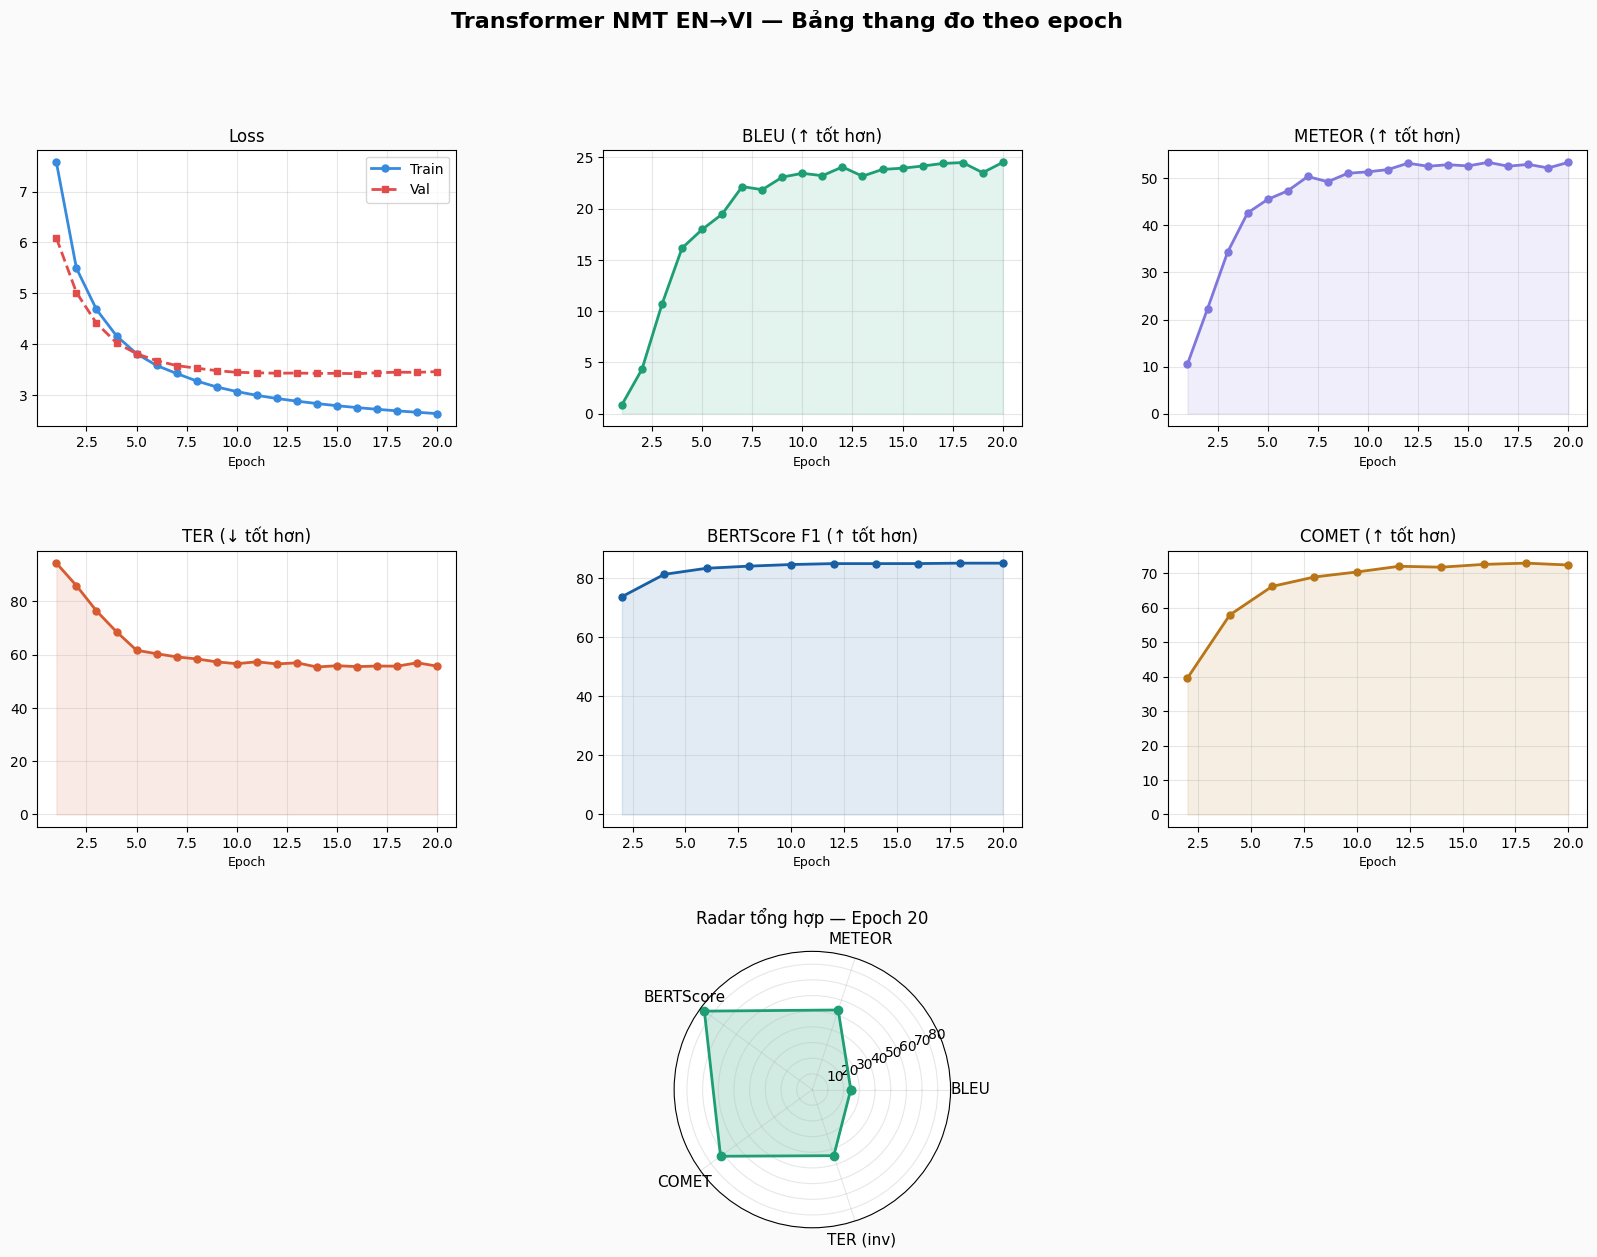

📊 Biểu đồ lưu: /kaggle/working/metrics_chart.png

📝 VÍ DỤ DỊCH:
  REF: Khi tôi còn nhỏ , Tôi nghĩ rằng Bắc Triều T iên là đất nước tốt nhất trên thế giới và tôi thường hát bài & quot ; Chúng ta chẳng có gì phải ghen tị . & quot ;
  HYP: Khi tôi còn nhỏ , tôi nghĩ đất nước mình là người giỏi nhất trên hành tinh , và tôi đã lớn lên hát một bài hát tên là & quot ; Không gì để En ghen tị . & quot ;

  REF: Tôi đã rất tự hào về đất nước tôi .
  HYP: Và tôi rất tự hào .

  REF: Ở trường , chúng tôi dành rất nhiều thời gian để học về cuộc đời của chủ tịch Kim II - S ung , nhưng lại không học nhiều về thế giới bên ngoài , ngoại trừ việc Hoa Kỳ , Hàn Quốc và Nhật Bản là kẻ thù của chúng tôi .
  HYP: Ở trường học , chúng tôi đã dành rất nhiều thời gian nghiên cứu lịch sử của Kim I l S ung , nhưng chúng tôi chưa bao giờ biết được nhiều về thế giới bên ngoài , ngoại trừ nước Mỹ , Nam Hàn Quốc là kẻ thù .


✅ Training xong! Best BLEU = 24.51


In [17]:
def train_one_epoch(model, loader, optimizer, criterion, scheduler, scaler, clip):
    model.train(); total = 0
    for src, tgt in loader:
        src, tgt = src.to(cfg.DEVICE), tgt.to(cfg.DEVICE)
        with autocast():                    # mixed precision T4
            pred = model(src, tgt[:, :-1])
            B, T, V = pred.shape
            loss = criterion(pred.reshape(B*T, V),
                             tgt[:, 1:].reshape(B*T))
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total += loss.item()
    return total / len(loader)

def eval_loss(model, loader, criterion):
    model.eval(); total = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(cfg.DEVICE), tgt.to(cfg.DEVICE)
            pred = model(src, tgt[:, :-1])
            B, T, V = pred.shape
            total += criterion(pred.reshape(B*T, V),
                                tgt[:, 1:].reshape(B*T)).item()
    return total / len(loader)

# ── Bắt đầu training ──────────────────────────────────────────
history   = []
best_bleu = 0.0
SAVE_PATH = '/kaggle/working/best_model.pt'

print('🚀 Bắt đầu training...\n')

for epoch in range(1, cfg.N_EPOCHS + 1):
    t0 = time.time()

    # Train
    tl = train_one_epoch(model, train_loader, optimizer,
                         criterion, scheduler, scaler, cfg.CLIP)
    # Val loss
    vl = eval_loss(model, val_loader, criterion)

    # Tính metrics — full (5 chỉ số) mỗi METRIC_EVERY epoch
    full = (epoch % cfg.METRIC_EVERY == 0) or (epoch == cfg.N_EPOCHS)
    print(f'Epoch {epoch}/{cfg.N_EPOCHS} — tính metrics {"đầy đủ" if full else "nhanh"}...')
    m, ex_hyps, ex_refs = compute_all_metrics(model, val_loader, val_srcs_raw, full=full)

    elapsed = time.time() - t0
    row = {
        'epoch'     : epoch,
        'train_loss': round(tl, 4),
        'val_loss'  : round(vl, 4),
        'BLEU'      : m['BLEU'],
        'METEOR'    : m['METEOR'],
        'TER'       : m['TER'],
        'BERTScore' : m['BERTScore'],
        'COMET'     : m['COMET'],
        'lr'        : scheduler._rate,
        'time_s'    : round(elapsed, 1)
    }
    history.append(row)

    # Lưu model tốt nhất theo BLEU
    if m['BLEU'] > best_bleu:
        best_bleu = m['BLEU']
        torch.save(model.state_dict(), SAVE_PATH)

    # Xoá output cũ rồi in lại toàn bộ
    clear_output(wait=True)

    # Header
    print('='*75)
    print(f'  Epoch {epoch}/{cfg.N_EPOCHS} | {elapsed:.0f}s | LR={scheduler._rate:.2e} | '
          f'Best BLEU={best_bleu:.2f}')
    print(f'  Loss Train={tl:.4f} | Loss Val={vl:.4f}')
    print(f'  BLEU={m["BLEU"]:.2f} | METEOR={m["METEOR"]:.2f} | TER={m["TER"]:.2f} | '
          f'BERTScore={m["BERTScore"]:.2f} | COMET={m["COMET"]:.2f}')
    print('='*75)

    # Bảng metrics
    print('\n📋 BẢNG CHỈ SỐ ĐÁNH GIÁ:')
    show_metrics_table(history)

    # Biểu đồ thang đo
    if full:
        print('\n📊 BIỂU ĐỒ THANG ĐO:')
        plot_metrics(history)

    # Ví dụ dịch
    print('\n📝 VÍ DỤ DỊCH:')
    for h, r in zip(ex_hyps, ex_refs):
        print(f'  REF: {r}')
        print(f'  HYP: {h}\n')

print(f'\n✅ Training xong! Best BLEU = {best_bleu:.2f}')

In [23]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=cfg.DEVICE))
model.eval()

test_srcs_raw = [test_data[i]['en'] for i in range(len(test_data))]
test_m, _, _  = compute_all_metrics(model, test_loader, test_srcs_raw,
                                     full=True)

print('\n' + '='*55)
print('  KẾT QUẢ CUỐI CÙNG TRÊN TẬP TEST')
print('='*55)
for k, v in test_m.items():
    bar = '█' * int(v/3)
    print(f'  {k:<12}: {v:>7.2f}  {bar}')
print('='*55)
show_metrics_table([{'epoch':'Test', 'train_loss':0, 'val_loss':0,
                      'lr':0, 'time_s':0, **test_m}])

  Đang dịch...

 BLEU/METEOR/TER xong.

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Predicting DataLoader 0: 100%|██████████| 10/10 [00:08<00:00,  1.24it/s]


 BERTScore/COMET xong.

  KẾT QUẢ CUỐI CÙNG TRÊN TẬP TEST
  BLEU        :   24.51  ████████
  METEOR      :   53.40  █████████████████
  TER         :   55.65  ██████████████████
  BERTScore   :   85.15  ████████████████████████████
  COMET       :   72.39  ████████████████████████
       train_loss  val_loss   BLEU  METEOR    TER  BERTScore
Epoch                                                       
Test            0         0  24.51    53.4  55.65      85.15


In [24]:
def dich(en_text):
    src = torch.tensor([encode(en_text)], dtype=torch.long).to(cfg.DEVICE)
    return decode_ids(model.translate(src))

demo = [
    "Hello, how are you?",
    "The weather is beautiful today.",
    "I want to learn Vietnamese.",
    "Machine translation is a very challenging task.",
    "The Transformer model has revolutionized natural language processing.",
    "Deep learning requires a large amount of training data.",
]

print('DEMO DỊCH EN → VI')
print('='*65)
for s in demo:
    print(f'EN: {s}')
    print(f'VI: {dich(s)}\n')

DEMO DỊCH EN → VI
EN: Hello, how are you?
VI: Xin chào , bạn làm thế nào ?

EN: The weather is beautiful today.
VI: Thời tiết rất đẹp .

EN: I want to learn Vietnamese.
VI: Tôi muốn học Việt Nam .

EN: Machine translation is a very challenging task.
VI: Dịch thuật là một nhiệm vụ rất khó khăn .

EN: The Transformer model has revolutionized natural language processing.
VI: Điện năng là cách mạng hoá ngôn ngữ tự nhiên .

EN: Deep learning requires a large amount of training data.
VI: Nh ảy xa hơn việc học tập cần một lượng lớn các tài liệu đào tạo .



In [25]:
pd.DataFrame(history).to_csv('/kaggle/working/training_history.csv', index=False)
pd.Series(test_m).to_csv('/kaggle/working/test_results.csv')
print('✅ Đã lưu: training_history.csv | test_results.csv | best_model.pt | metrics_chart.png\n')

✅ Đã lưu: training_history.csv | test_results.csv | best_model.pt | metrics_chart.png



In [26]:
import shutil, os

shutil.make_archive(
    base_name="/kaggle/working/neuralmachinetranslation",
    format="zip",
    root_dir="/kaggle/working"
)

print("✅ Đã tạo: /kaggle/working/neuralmachinetranslation.zip")
print(f"📦 Size: {os.path.getsize('/kaggle/working/neuralmachinetranslation.zip') / 1024 / 1024:.1f} MB")

✅ Đã tạo: /kaggle/working/neuralmachinetranslation.zip
📦 Size: 58.5 MB
